In [1]:
# Now let's all the necessary libraries here 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
import keras 
import keras_tuner as kt

from keras.callbacks import EarlyStopping
from keras.optimizers import Adam,SGD,RMSprop
from keras.models import Sequential
from keras.layers import Input,Activation
from keras.layers import Dropout,Dense,BatchNormalization

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df.shape

(1338, 7)

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
# This is also one of the famous dataset so we just need to map sex and age into binary and make seperate columns for region usng onc 

In [7]:
df['sex'] = df['sex'].map({
                                'female': 0,
                                'male' : 1
})

In [8]:
df['smoker'] = df['smoker'].map({
                                'no': 0,
                                'yes' : 1
})

In [9]:
df = pd.get_dummies(df,columns=['region'],dtype=int) # OneHotEncode using get_dummmies

In [10]:
df.head() # All set

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


In [11]:
# I also want to see the corr of the values with charges
df.corr()['charges'] # We won't remove the non significant columns here for now ; maybe later during experimenting

age                 0.299008
sex                 0.057292
bmi                 0.198341
children            0.067998
smoker              0.787251
charges             1.000000
region_northeast    0.006349
region_northwest   -0.039905
region_southeast    0.073982
region_southwest   -0.043210
Name: charges, dtype: float64

In [173]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='str')

In [12]:
# Now we will split the data into X,y and then training and testing set for our ann

In [192]:
X,y = df.drop(columns=['charges']),df['charges']

In [193]:
X_train , X_test , y_train , y_test = train_test_split(
                                                            X,y,
                                                            test_size = 0.2,
                                                            random_state = 42
)

In [194]:
# Now we have one last step left that is Normalization which we will do using StandardScaler
scale = StandardScaler()
scale.fit(X_train)

X_train_scalled = scale.transform(X_train)
X_test_scalled = scale.transform(X_test)

In [195]:
# Now we are readly for the model building phase

In [196]:
# We will be using the linear model for the outpu layer
# Hidden Layer = 2 for now and the Activation will be relu
# No of neurons will be 12 for each layer now

In [ ]:
# model = Sequential()

# n_layers = 2

# for _ in range(n_layers) :
#     model.add(Dense(30,kernel_initializer='he_normal'))
#     model.add(Activation('relu'))
#     model.add(Dropout(0.3))

# model.add(Dense(1))
# model.add(Activation('linear'))

# model.compile(optimizer='adam',loss='mean_squared_error',metrics=['mae','root_mean_squared_error'])

In [ ]:
# stop_early = EarlyStopping(
#     monitor='val_root_mean_squared_error',       
#     patience=10,                     
#     restore_best_weights=True
# )

In [226]:
# history = model.fit(
#             X_train,y_train,
#             epochs = 100,
#             validation_data = (X_test,y_test),
#             verbose = 1,
#             callbacks=stop_early
# )

In [229]:
def build_model(hp):

    model = Sequential()

    model.add(Input(shape=(X.shape[1],)))

    num_layers = hp.Int(
                            'no_of_layers',
                            min_value = 2,
                            max_value = 3,
                            step = 1
    )

    dropout_rate = hp.Float(
                                    f'dropout', 
                                    min_value=0.0, 
                                    max_value=0.4, 
                                    step=0.1
        )
    
    num_neurons = hp.Int(
                            f'no_of_nodes_in_layer',
                            min_value = 20,
                            max_value = 30,
                            step = 2
        )

    for i in range(num_layers):
        
        model.add(Dense(num_neurons,kernel_initializer='he_normal'))
        model.add(Activation('relu'))
        model.add(Dropout(dropout_rate))

    model.add(Dense(1))
    model.add(Activation('linear'))


    learning_rate = hp.Choice(
                                'learning_rates' ,         
                                values = [1e-2, 1e-3] 
        )


    model.compile(
        optimizer= Adam(learning_rate=learning_rate),
        loss='mean_squared_error',
        metrics=['mae','root_mean_squared_error']
    )

    return model



In [230]:
# Hyperband 
tuner = kt.Hyperband(
                        hypermodel = build_model,
                        objective = 'val_root_mean_squared_error',
                        max_epochs = 20,
                        factor = 2,
                        directory = 'insurance_tuning_small',
                        project_name = 'neural-network-insurance-1'
)

In [231]:
stop_early = EarlyStopping(
    monitor='val_root_mean_squared_error',       
    patience=10,                     
    restore_best_weights=True
)

In [232]:
tuner.search(
    X_train, y_train,                         
    validation_data=(X_test,y_test),   
    callbacks=[stop_early]              
)

Trial 61 Complete [00h 00m 52s]
val_root_mean_squared_error: 11545.0625

Best val_root_mean_squared_error So Far: 6159.50341796875
Total elapsed time: 00h 34m 59s

Search: Running Trial #62

Value             |Best Value So Far |Hyperparameter
3                 |3                 |no_of_layers
0.1               |0.2               |dropout
28                |26                |no_of_nodes_in_layer
0.001             |0.01              |learning_rates
20                |20                |tuner/epochs
10                |10                |tuner/initial_epoch
3                 |4                 |tuner/bracket
3                 |4                 |tuner/round
0059              |0035              |tuner/trial_id

Epoch 11/20


c:\Users\hp\Desktop\DL\.venv-1\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 182ms/step - loss: 132207872.0000 - mae: 8982.8896 - root_mean_squared_error: 11498.1680 - val_loss: 132679264.0000 - val_mae: 9131.1279 - val_root_mean_squared_error: 11518.6484
Epoch 12/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - loss: 132526528.0000 - mae: 8925.1992 - root_mean_squared_error: 11512.0166 - val_loss: 132508304.0000 - val_mae: 9184.9033 - val_root_mean_squared_error: 11511.2256
Epoch 13/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 132586200.0000 - mae: 9014.6182 - root_mean_squared_error: 11514.6084 - val_loss: 132439760.0000 - val_mae: 9166.1787 - val_root_mean_squared_error: 11508.2471
Epoch 14/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - loss: 132188744.0000 - mae: 8960.5352 - root_mean_squared_error: 11497.3359 - val_loss: 132375688.0000 - val_mae: 9146.7930 - val_root_mean_squared_error: 11505.4639
Epoch 15/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - loss: 131603072.0000 - mae: 8784.2012 - root_mean_squared_error: 11471.8

KeyboardInterrupt: 

In [233]:
tuner.results_summary(num_trials=1)

Results summary
Results in insurance_tuning_small\neural-network-insurance-1
Showing 1 best trials
Objective(name="val_root_mean_squared_error", direction="min")

Trial 0038 summary
Hyperparameters:
no_of_layers: 3
dropout: 0.2
no_of_nodes_in_layer: 26
learning_rates: 0.01
tuner/epochs: 20
tuner/initial_epoch: 10
tuner/bracket: 4
tuner/round: 4
tuner/trial_id: 0035
Score: 6159.50341796875


In [234]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)

In [235]:
history = best_model.fit(
    X_train, y_train, 
    epochs=100, 
    validation_data=(X_test, y_test),
    callbacks=[stop_early]
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 165ms/step - loss: 286253600.0000 - mae: 11963.5312 - root_mean_squared_error: 16919.0312 - val_loss: 163801200.0000 - val_mae: 7734.5078 - val_root_mean_squared_error: 12798.4844
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 145956368.0000 - mae: 8958.5088 - root_mean_squared_error: 12081.2402 - val_loss: 133772392.0000 - val_mae: 8881.5117 - val_root_mean_squared_error: 11566.0020
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - loss: 137699424.0000 - mae: 8897.0381 - root_mean_squared_error: 11734.5400 - val_loss: 132869472.0000 - val_mae: 8840.3105 - val_root_mean_squared_error: 11526.9023
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 136561248.0000 - mae: 8870.2188 - root_mean_squared_error: 11685.9424 - val_loss: 130896128.0000 - val_mae: 9276.5713 - val_root_mean_squared_error: 11440.9844
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 137268656.0000 - mae: 8879.1406 - root_mean_squared_er

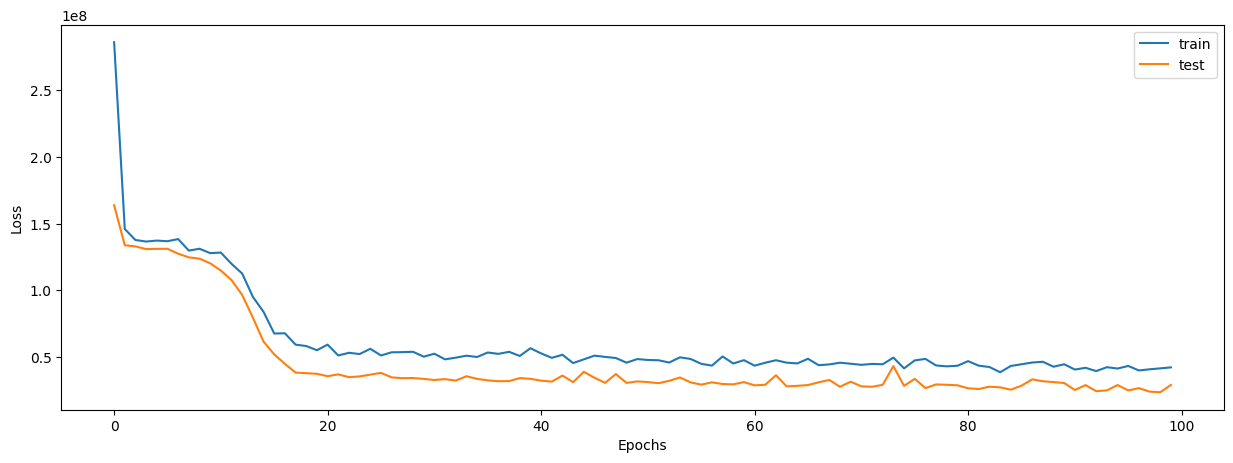

In [236]:
# Plot the model performance 
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

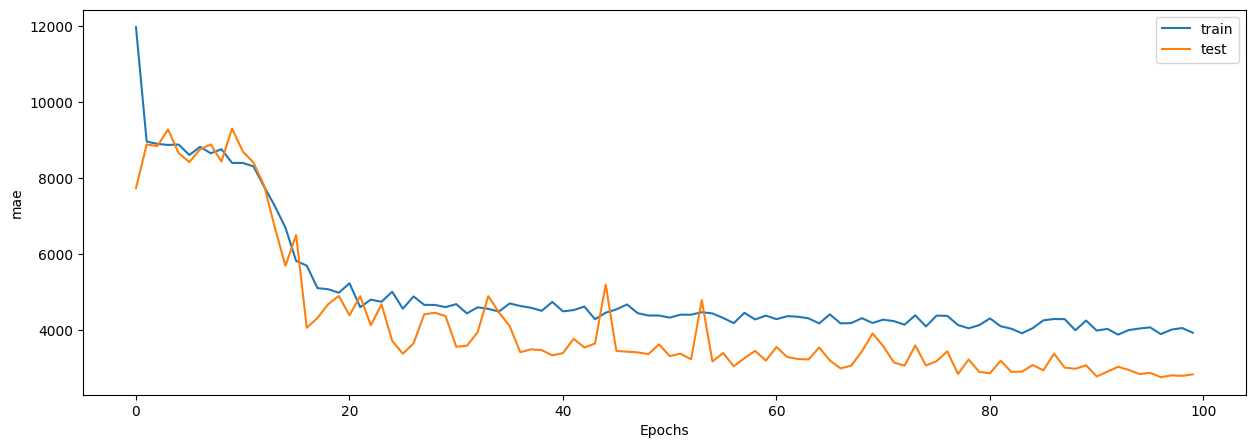

In [237]:
# Plot the model performance 
plt.figure(figsize=(15,5))
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='test')
plt.xlabel('Epochs')
plt.ylabel('mae')
plt.legend()
plt.show()

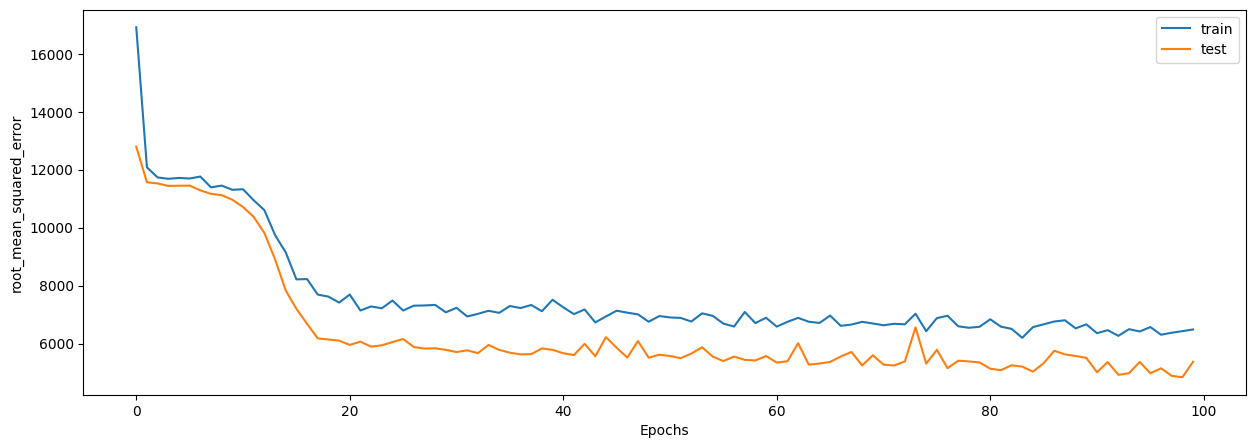

In [238]:
# Plot the model performance 
plt.figure(figsize=(15,5))
plt.plot(history.history['root_mean_squared_error'], label='train')
plt.plot(history.history['val_root_mean_squared_error'], label='test')
plt.xlabel('Epochs')
plt.ylabel('root_mean_squared_error')
plt.legend()
plt.show()